In [3]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.loader import DataLoader

from torch_geometric.nn import (
    GATConv,
    global_mean_pool,
    global_max_pool
) 
import joblib

from src.models import trackGAT

from sklearn.metrics import r2_score

import matplotlib.pyplot as plt

In [2]:
import sys
import os

project_root = os.path.abspath("..")
sys.path.append(project_root)

In [4]:
model = trackGAT()

checkpoint = torch.load(
    r"C:\Projects\SPD-Track-Parameter-Prediction\models\px_py_pz_best_model.pt",
    map_location=torch.device("cpu")
)

model.load_state_dict(checkpoint["model_state_dictionary"])
model.eval()

C:\Users\js731\AppData\Local\Temp\ipykernel_12336\2748621823.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


trackGAT(
  (gat1): GATConv(7, 128, heads=1)
  (gat2): GATConv(128, 128, heads=1)
  (dropout): Dropout(p=0.2, inplace=False)
  (linear): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=3, bias=True)
  )
)

In [5]:
test_dataset = torch.load("test_dataset.pt")

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

C:\Users\js731\AppData\Local\Temp\ipykernel_12336\1299583217.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  test_dataset = torch.load("test_dataset.pt")


In [6]:
# calculate pt and momentum through formula


target_scaler = joblib.load(
    r"C:\Projects\SPD-Track-Parameter-Prediction\notebooks\target_scaler.pkl"
)
# step 1:- sabse pehle muje predicted px, py, pz ko access krna h and store krna h

model.eval()

pred_px = []
pred_py = []
pred_pz = []

true_pt = []
true_momentum = []

calculate_pt = []
calculate_momentum = []

with torch.no_grad():

    for batch in test_loader:

        # model prediction
        prediction = model(batch.x, batch.edge_index, batch.batch)

        # prediction ko numpy me convert karo
        pred = prediction.cpu().numpy()

        # normalized values ko original values me convert karo
        pred_original = target_scaler.inverse_transform(pred)

        # original predicted px, py, pz
        px = pred_original[:, 0]
        py = pred_original[:, 1]
        pz = pred_original[:, 2]

        # step 2:- predicted px, py, pz se pt and momentum calculate karo

        pt = np.sqrt(px**2 + py**2)
        momentum = np.sqrt(px**2 + py**2 + pz**2)

        # step 3:- calculated pt and momentum ko list me store karo

        pred_px.append(px)
        pred_py.append(py)
        pred_pz.append(pz)

        calculate_pt.append(pt)
        calculate_momentum.append(momentum)

        # step 4:- actual normalized labels ko original values me convert karo

        true = batch.y.cpu().numpy()

        true_original = target_scaler.inverse_transform(true)

        true_px = true_original[:, 0]
        true_py = true_original[:, 1]
        true_pz = true_original[:, 2]

        # actual pt and momentum calculate karo

        actual_pt = np.sqrt(true_px**2 + true_py**2)
        actual_momentum = np.sqrt(true_px**2 + true_py**2 + true_pz**2)

        true_pt.append(actual_pt)
        true_momentum.append(actual_momentum)

# step 5:- lists ko ek array me convert karo

calculate_pt = np.concatenate(calculate_pt)
calculate_momentum = np.concatenate(calculate_momentum)

true_pt = np.concatenate(true_pt)
true_momentum = np.concatenate(true_momentum)

# MAE calculate karo

pt_mae = np.mean(np.abs(calculate_pt - true_pt))
momentum_mae = np.mean(np.abs(calculate_momentum - true_momentum))



In [7]:
print("PT MAE :", pt_mae)
print("Momentum MAE :", momentum_mae)

print("PT Range :")
print(np.min(true_pt), np.max(true_pt))

print("Momentum Range :")
print(np.min(true_momentum), np.max(true_momentum))

pt_rmse = np.sqrt(np.mean((calculate_pt - true_pt)**2))
momentum_rmse = np.sqrt(np.mean((calculate_momentum - true_momentum)**2))

print("PT RMSE :", pt_rmse)
print("Momentum RMSE :", momentum_rmse)

PT MAE : 0.29332498
Momentum MAE : 0.40339822
PT Range :
0.2300563 2.339576
Momentum Range :
0.23797046 13.074576
PT RMSE : 0.34789953
Momentum RMSE : 0.5849986


In [8]:
pt_r2 = r2_score(true_pt, calculate_pt)
momentum_r2 = r2_score(true_momentum, calculate_momentum)

print("PT R² :", pt_r2)
print("Momentum R² :", momentum_r2)

PT R² : 0.6734347939491272
Momentum R² : 0.6588205099105835


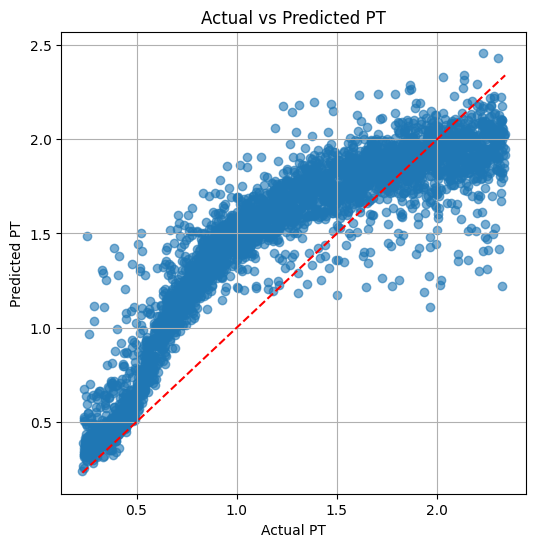

In [9]:
plt.figure(figsize=(6,6))

plt.scatter(true_pt,calculate_pt,alpha=0.6)

# Ideal prediction line
plt.plot([true_pt.min(), true_pt.max()],[true_pt.min(), true_pt.max()],'r--')

plt.xlabel("Actual PT")
plt.ylabel("Predicted PT")
plt.title("Actual vs Predicted PT")

plt.grid(True)
plt.show()

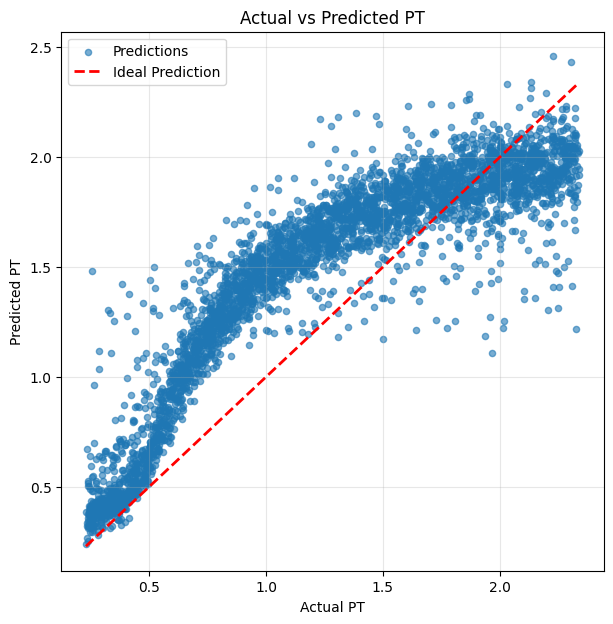

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(
    true_pt,
    calculate_pt,
    alpha=0.6,
    s=20,
    label="Predictions"
)

# Ideal line
plt.plot(
    [true_pt.min(), true_pt.max()],
    [true_pt.min(), true_pt.max()],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Ideal Prediction"
)

plt.xlabel("Actual PT")
plt.ylabel("Predicted PT")
plt.title("Actual vs Predicted PT")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

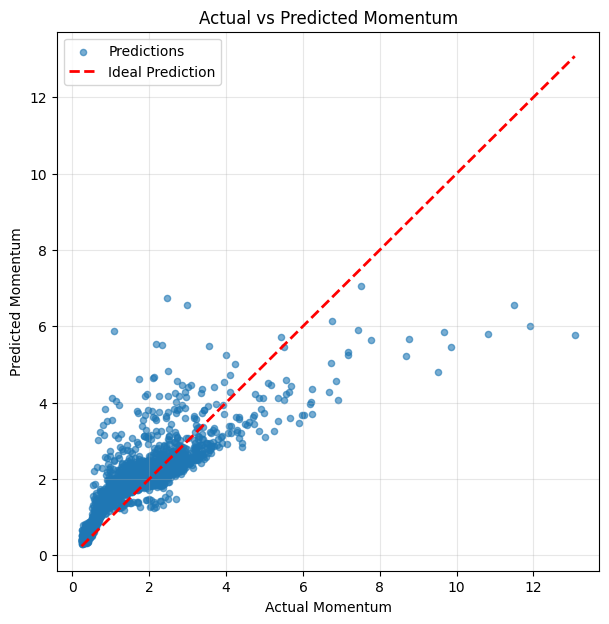

In [11]:
plt.figure(figsize=(7,7))

plt.scatter(
    true_momentum,
    calculate_momentum,
    alpha=0.6,
    s=20,
    label="Predictions"
)

plt.plot(
    [true_momentum.min(), true_momentum.max()],
    [true_momentum.min(), true_momentum.max()],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Ideal Prediction"
)

plt.xlabel("Actual Momentum")
plt.ylabel("Predicted Momentum")
plt.title("Actual vs Predicted Momentum")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

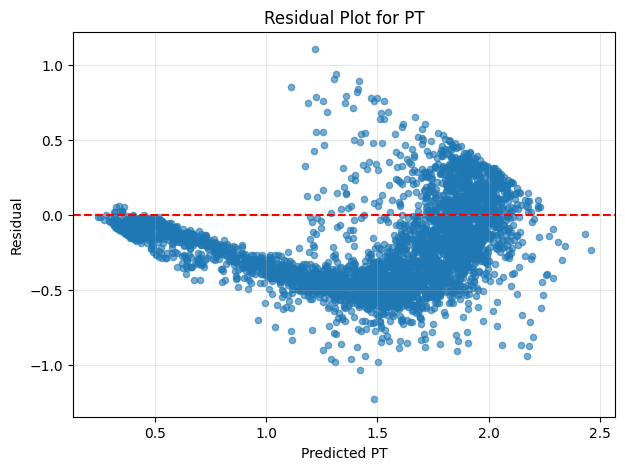

In [ ]:
# Residual plot
pt_residual= true_pt - calculate_pt
momentum_residual = true_momentum - calculate_momentum
plt.figure(figsize=(7,5))

plt.scatter(calculate_pt, pt_residual,alpha=0.6,s=20 )

plt.axhline(y=0, color="red",linestyle="--")

plt.xlabel("Predicted PT")
plt.ylabel("Residual")
plt.title("Residual Plot for PT")

plt.grid(alpha=0.3)

plt.show()

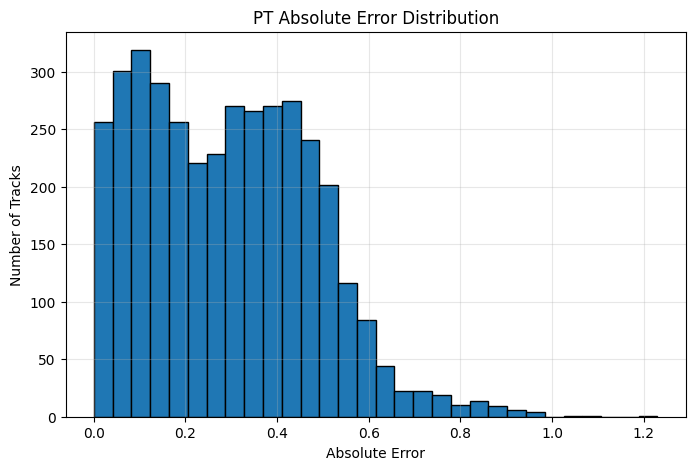

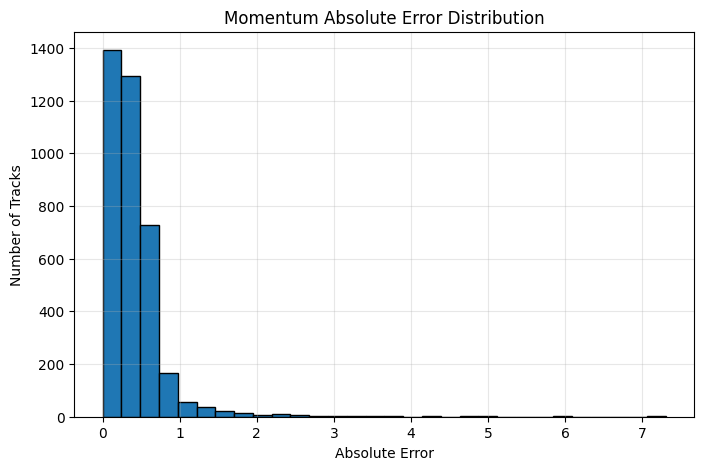

In [14]:
# error distribution histogram 
pt_error = np.abs(true_pt - calculate_pt)
momentum_error = np.abs(true_momentum - calculate_momentum)
plt.figure(figsize=(8,5))

plt.hist(
    pt_error,
    bins=30,
    edgecolor="black"
)

plt.xlabel("Absolute Error")
plt.ylabel("Number of Tracks")
plt.title("PT Absolute Error Distribution")

plt.grid(alpha=0.3)

plt.show()


plt.figure(figsize=(8,5))

plt.hist(
    momentum_error,
    bins=30,
    edgecolor="black"
)

plt.xlabel("Absolute Error")
plt.ylabel("Number of Tracks")
plt.title("Momentum Absolute Error Distribution")

plt.grid(alpha=0.3)

plt.show()

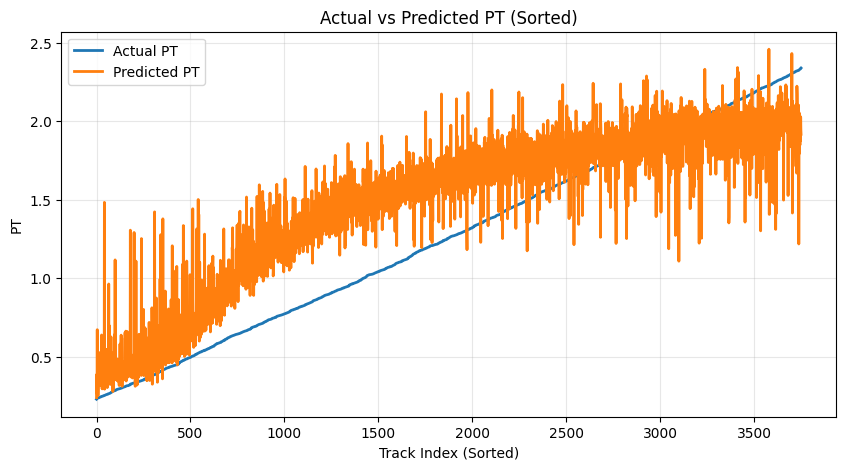

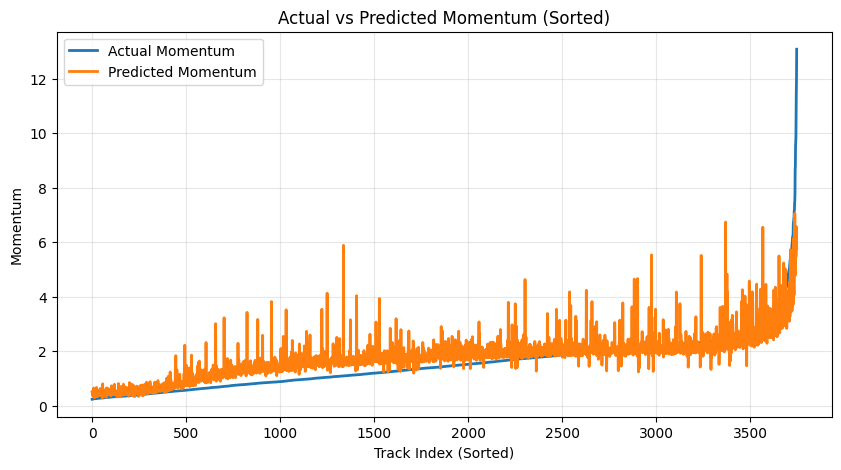

In [16]:
# sort according to actual PT
sorted_index = np.argsort(true_pt)

true_pt_sorted = true_pt[sorted_index]
calculate_pt_sorted = calculate_pt[sorted_index]

plt.figure(figsize=(10,5))

plt.plot(
    true_pt_sorted,
    label="Actual PT",
    linewidth=2
)

plt.plot(
    calculate_pt_sorted,
    label="Predicted PT",
    linewidth=2
)

plt.xlabel("Track Index (Sorted)")
plt.ylabel("PT")
plt.title("Actual vs Predicted PT (Sorted)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()


sorted_index = np.argsort(true_momentum)

true_momentum_sorted = true_momentum[sorted_index]
calculate_momentum_sorted = calculate_momentum[sorted_index]

plt.figure(figsize=(10,5))

plt.plot(
    true_momentum_sorted,
    label="Actual Momentum",
    linewidth=2
)

plt.plot(
    calculate_momentum_sorted,
    label="Predicted Momentum",
    linewidth=2
)

plt.xlabel("Track Index (Sorted)")
plt.ylabel("Momentum")
plt.title("Actual vs Predicted Momentum (Sorted)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

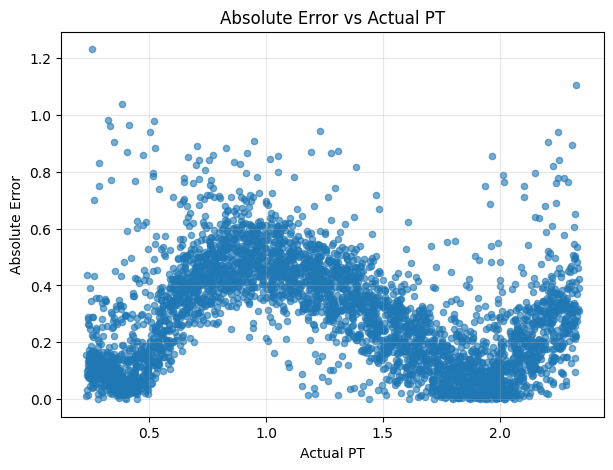

In [17]:
pt_error = np.abs(true_pt - calculate_pt)

plt.figure(figsize=(7,5))

plt.scatter(
    true_pt,
    pt_error,
    alpha=0.6,
    s=20
)

plt.xlabel("Actual PT")
plt.ylabel("Absolute Error")
plt.title("Absolute Error vs Actual PT")

plt.grid(alpha=0.3)

plt.show()